# **12. Análisis Exploratorio de Datos**

## Programacion Avanzada - Python <br>

**Docentes:**
```
- Cristian Guarnizo-Lemus
- Esteban Gonzalez-Valencia
```

A continuacion importamos la librerias que necesitamos para este notebook.

In [107]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

***
# **12.1. Auto MPG Dataset**
Esta base de datos se emplea para hacer prediccion (modelo de regresion) a partir del peso, potencia, cilindraje y desplazamiento de diferentes tipos de vehiculos.

Usamos la libreria Pandas para obtener una descrpicion estadistica del conjunto de datos. La descripcion de esta base de datos puede ser encontrada en [UCI_MGP_data_link](https://archive.ics.uci.edu/ml/datasets/auto+mpg). Continuamos definiendo los nombres de las columnas y leemos los valores del archivo que descargamos.

**Descripción General**

El dataset Auto-Mpg es un conjunto de datos clásico utilizado para predecir el consumo de combustible en ciclo urbano, medido en millas por galón (mpg). Los datos provienen de la librería StatLib de la Universidad Carnegie Mellon y fueron presentados originalmente en la Exposición de la Asociación Americana de Estadística en 1983. Esta versión final consta de 398 instancias y un total de 9 atributos (8 variables predictoras y 1 variable de clase).

* A continuación se detallan las columnas que componen el DataFrame:

| # | Atributo | Tipo de Dato | Descripción |
| :--- | :--- | :--- | :--- |
| 1 | **mpg** | Continuo | Millas por galón; es la variable objetivo a predecir. |
| 2 | **cylinders** | Discreto | Número de cilindros del motor. |
| 3 | **displacement** | Continuo | Desplazamiento o cilindrada del motor. |
| 4 | **horsepower** | Continuo | Potencia del motor (caballos de fuerza). Contiene 6 valores faltantes. |
| 5 | **weight** | Continuo | Peso total del vehículo. |
| 6 | **acceleration** | Continuo | Tiempo de aceleración del vehículo. |
| 7 | **model year** | Discreto | Año del modelo del vehículo. |
| 8 | **origin** | Discreto | Código de origen del vehículo (1: USA, 2: Europa, 3: Japón). |
| 9 | **car name** | String | Nombre y modelo del vehículo (identificador único). |

> **Nota técnica:** Recuerda que en archivos como `auto-mpg.data`, los valores faltantes en `horsepower` están representados con un signo de interrogación (`?`)

***
## **12.1.1. Cargar el dataset**

In [108]:
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight','Acceleration', 'Model Year', 'Origin']
raw_dataset = pd.read_csv(URL, names=column_names, na_values = "?", comment='\t', sep=" ", skipinitialspace=True)

dataset = raw_dataset.copy()
dataset

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1


***
## **12.1.2. Limpiar el dataset**

Revisamos si los datos contienen valores faltantes, vacíos o nulos, conocidos como "**NaN**" (Not a Number), si es asi, los eliminamos.

La siguiente linea de comando nos indica cuantos registros son "**NaN**".

In [109]:
dataset.isna().sum()

,0
MPG,0
Cylinders,0
Displacement,0
Horsepower,6
Weight,0
Acceleration,0
Model Year,0
Origin,0


Para mantener este ejemplo sencillo, eliminamos las final con "**NaN**" ejecutando la siguiente linea.

In [110]:
# Evaluamos cuáles columnas tiene datos faltantes
print("Valores nulos ANTES del manejo:")
print(dataset.isnull().sum()[dataset.isnull().sum() > 0])

Valores nulos ANTES del manejo:
Horsepower    6
dtype: int64


In [111]:
dataset2 = dataset.dropna()
print("Valores nulos DESPUÉS del manejo:")
print(dataset2.isnull().sum()[dataset2.isnull().sum() > 0])

Valores nulos DESPUÉS del manejo:
Series([], dtype: int64)


* Ahora verificamos y si es necesario, eliminamos los valores duplicados

In [112]:
dataset2.duplicated().sum()

np.int64(0)

In [113]:
duplicates_before = dataset2.duplicated().sum()                             # Esta línea cuenta las filas duplicadas tiene el dataset
if duplicates_before > 0:
    dataset2.drop_duplicates(inplace=True)                                  # Esta línea elimina las filas duplicadas
    print(f"Se eliminaron {duplicates_before} registros duplicados.")
else:
    print("No se encontraron registros duplicados.")

No se encontraron registros duplicados.


La columna "Origin" usa un valor entero para representa el pais donde el carro fue construido.
Si le pasas estos números (1, 2, 3) directamente a un modelo de regresión, el algoritmo podría pensar erróneamente que $3 > 2 > 1$ (que Japón es "mayor" que USA), lo cual no tiene sentido lógico.

* El One-Hot Encoding soluciona esto creando una nueva columna para cada categoría.

In [114]:
dataset2.head(3)

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1


In [115]:
dataset2 = pd.get_dummies(dataset2, columns=['Origin'])
dataset2.head(3)

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin_1,Origin_2,Origin_3
0,18.0,8,307.0,130.0,3504.0,12.0,70,True,False,False
1,15.0,8,350.0,165.0,3693.0,11.5,70,True,False,False
2,18.0,8,318.0,150.0,3436.0,11.0,70,True,False,False


In [116]:
dataset2 = dataset2.rename(columns={"Origin_1":"USA", "Origin_2":"Europe", "Origin_3":"Japan"})
dataset2.head(3)

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,USA,Europe,Japan
0,18.0,8,307.0,130.0,3504.0,12.0,70,True,False,False
1,15.0,8,350.0,165.0,3693.0,11.5,70,True,False,False
2,18.0,8,318.0,150.0,3436.0,11.0,70,True,False,False


In [117]:
## De forma alternativa
#origin = dataset.pop('Origin')

#dataset['USA'] = (origin == 1)*1.0
#dataset['Europe'] = (origin == 2)*1.0
#dataset['Japan'] = (origin == 3)*1.0
#dataset.tail()

***
# **12.2. Analisis Exploratorio de los datos**

## **12.2.1. Algunas Medidas Estadisticas**

In [118]:
# Mostar información de DataFrame
dataset2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           392 non-null    float64
 1   Cylinders     392 non-null    int64  
 2   Displacement  392 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        392 non-null    float64
 5   Acceleration  392 non-null    float64
 6   Model Year    392 non-null    int64  
 7   USA           392 non-null    bool   
 8   Europe        392 non-null    bool   
 9   Japan         392 non-null    bool   
dtypes: bool(3), float64(5), int64(2)
memory usage: 25.6 KB


In [119]:
# Mostrar información estadística del Dataframe
dataset2.describe()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


## **12.2.2. Explorar el dataset**

In [120]:
# Mostrar las primeras 5 filas del dataframe
dataset2.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,USA,Europe,Japan
0,18.0,8,307.0,130.0,3504.0,12.0,70,True,False,False
1,15.0,8,350.0,165.0,3693.0,11.5,70,True,False,False
2,18.0,8,318.0,150.0,3436.0,11.0,70,True,False,False
3,16.0,8,304.0,150.0,3433.0,12.0,70,True,False,False
4,17.0,8,302.0,140.0,3449.0,10.5,70,True,False,False


In [121]:
# Mostrar el "tamaño" del dataframe
dataset2.shape

(392, 10)

In [122]:
# Mostrar los títulos de las columnas del dataframe
dataset2.columns

Index(['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
       'Acceleration', 'Model Year', 'USA', 'Europe', 'Japan'],
      dtype='object')

***
# **12.3. Visualizar la frecuencia de los datos mediante graficos como histogramas**

## **12.3.1. Graficar todos los histogramas**



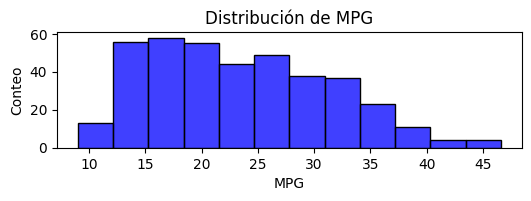

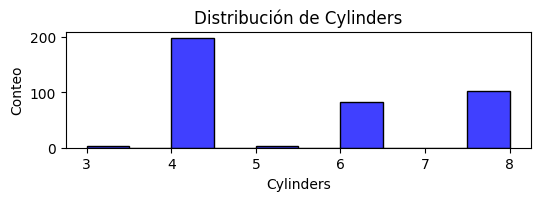

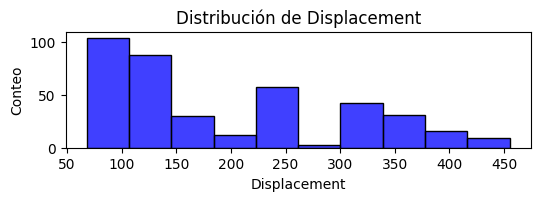

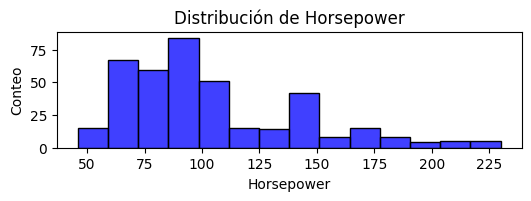

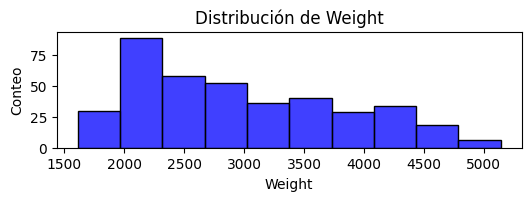

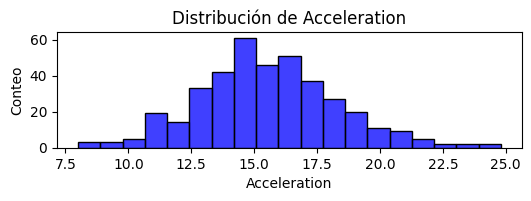

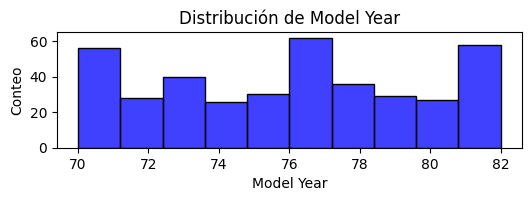

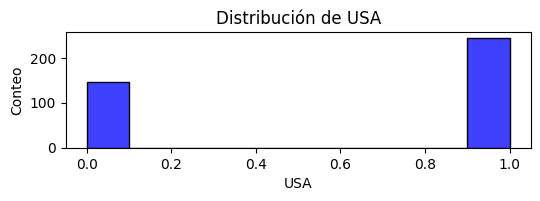

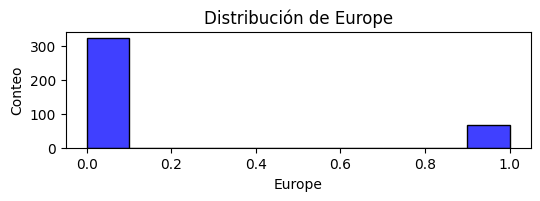

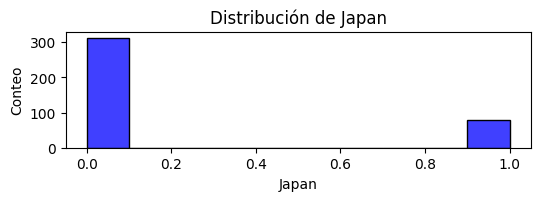

In [123]:
# Obtener una lista de todas las columnas en tu DataFrame 'data'
columnas = dataset2.columns

for columna in columnas:
    plt.figure(figsize=(6, 1.5))
    sns.histplot(dataset2[columna], kde=False, color='blue', edgecolor='black')
    plt.xlabel(columna)
    plt.ylabel('Conteo')
    plt.title(f'Distribución de {columna}')
    plt.show()

***
## **12.3.2. Graficar los histogramas de las variables de interés**

**IMPORTANTE**: el parámetro `bins` permite modificar la cantidad (y por consiguiente, el ancho) de las columnas del histograma.

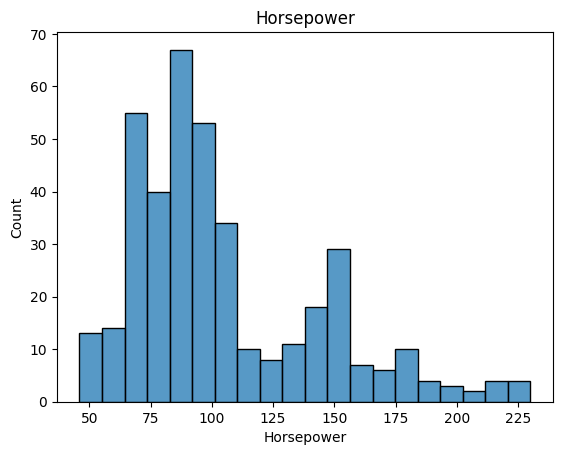

In [124]:
sns.histplot(dataset2['Horsepower'], kde=False, bins=20)
plt.title('Horsepower')
plt.show()

***
# **12.4. Diagramas de dispersión (Scatter plot)**

## **12.4.1. Graficar los diagramas de dispersión de las variables de interés**

In [125]:
dataset2.columns

Index(['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
       'Acceleration', 'Model Year', 'USA', 'Europe', 'Japan'],
      dtype='object')

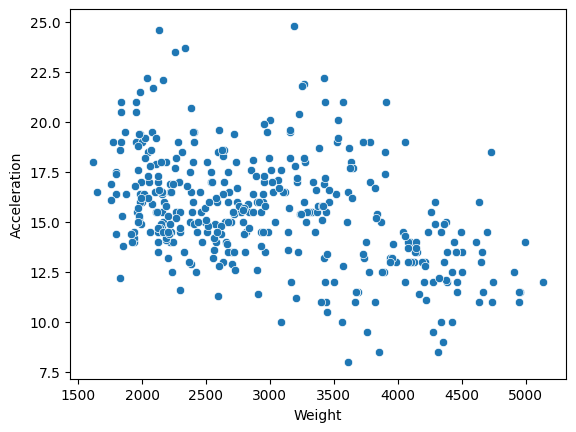

In [126]:
sns.scatterplot(x='Weight', y='Acceleration', data=dataset2)
plt.show()

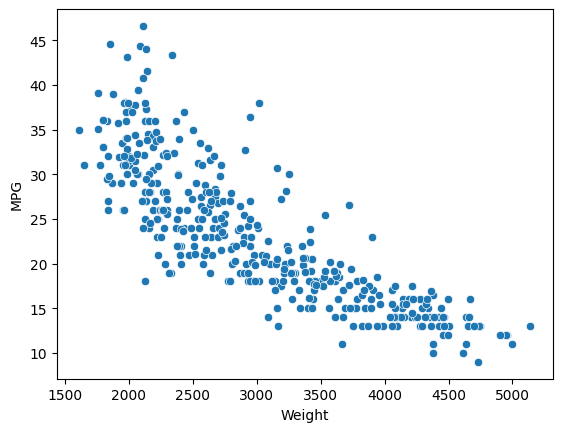

In [127]:
sns.scatterplot(x='Weight', y='MPG', data=dataset2)
plt.show()

**Segmentación por categorías:**

Al usar el parámetro `hue`, el gráfico separa los puntos por colores según si el estudiante completó o no el curso de preparación. Esto es clave para ver si la preparación realmente desplaza las nubes de puntos hacia puntajes más altos.

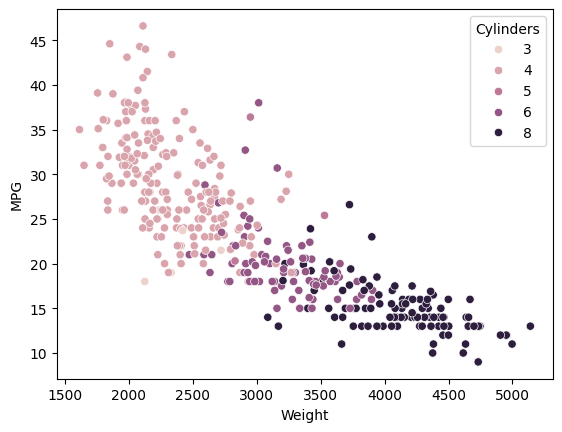

In [128]:
sns.scatterplot(x='Weight', y='MPG', hue='Cylinders', data=dataset2)
plt.show()

## **12.4.2. Gráfico de pares o matriz de dispersión (pairplot)**

Conocido como gráfico de pares o matriz de dispersión, es una herramienta de visualización de datos de la librería Seaborn que permite ver las relaciones de todas las variables numéricas de un dataset de forma simultánea.

En lugar de crear gráficos uno por uno, el pairplot genera una cuadrícula donde cada variable se cruza con las demás, permitiéndote identificar patrones, correlaciones y distribuciones en una sola imagen.

* **Matriz de correlación visual:** Es la forma más rápida de ver cómo interactúan todas las variables numéricas entre sí.

* **Distribuciones en la diagonal:** En la línea diagonal (donde una variable se cruza consigo misma), el gráfico muestra un histograma o una curva de densidad (KDE), permitiéndote ver cómo se distribuyen los datos de esa columna específica.

* **Relaciones bivariadas:** En los cuadros restantes, muestra gráficos de dispersión (scatter plots) que revelan si existe una relación lineal, exponencial o si no hay ninguna relación entre dos variables.


Ahora observamos las relaciones de que existen entre los datos, por medio de un scatter plot, donde en la diagonal estimamos la densidad de probabilidad por medio de KDE (Kernel Density Estimatio).

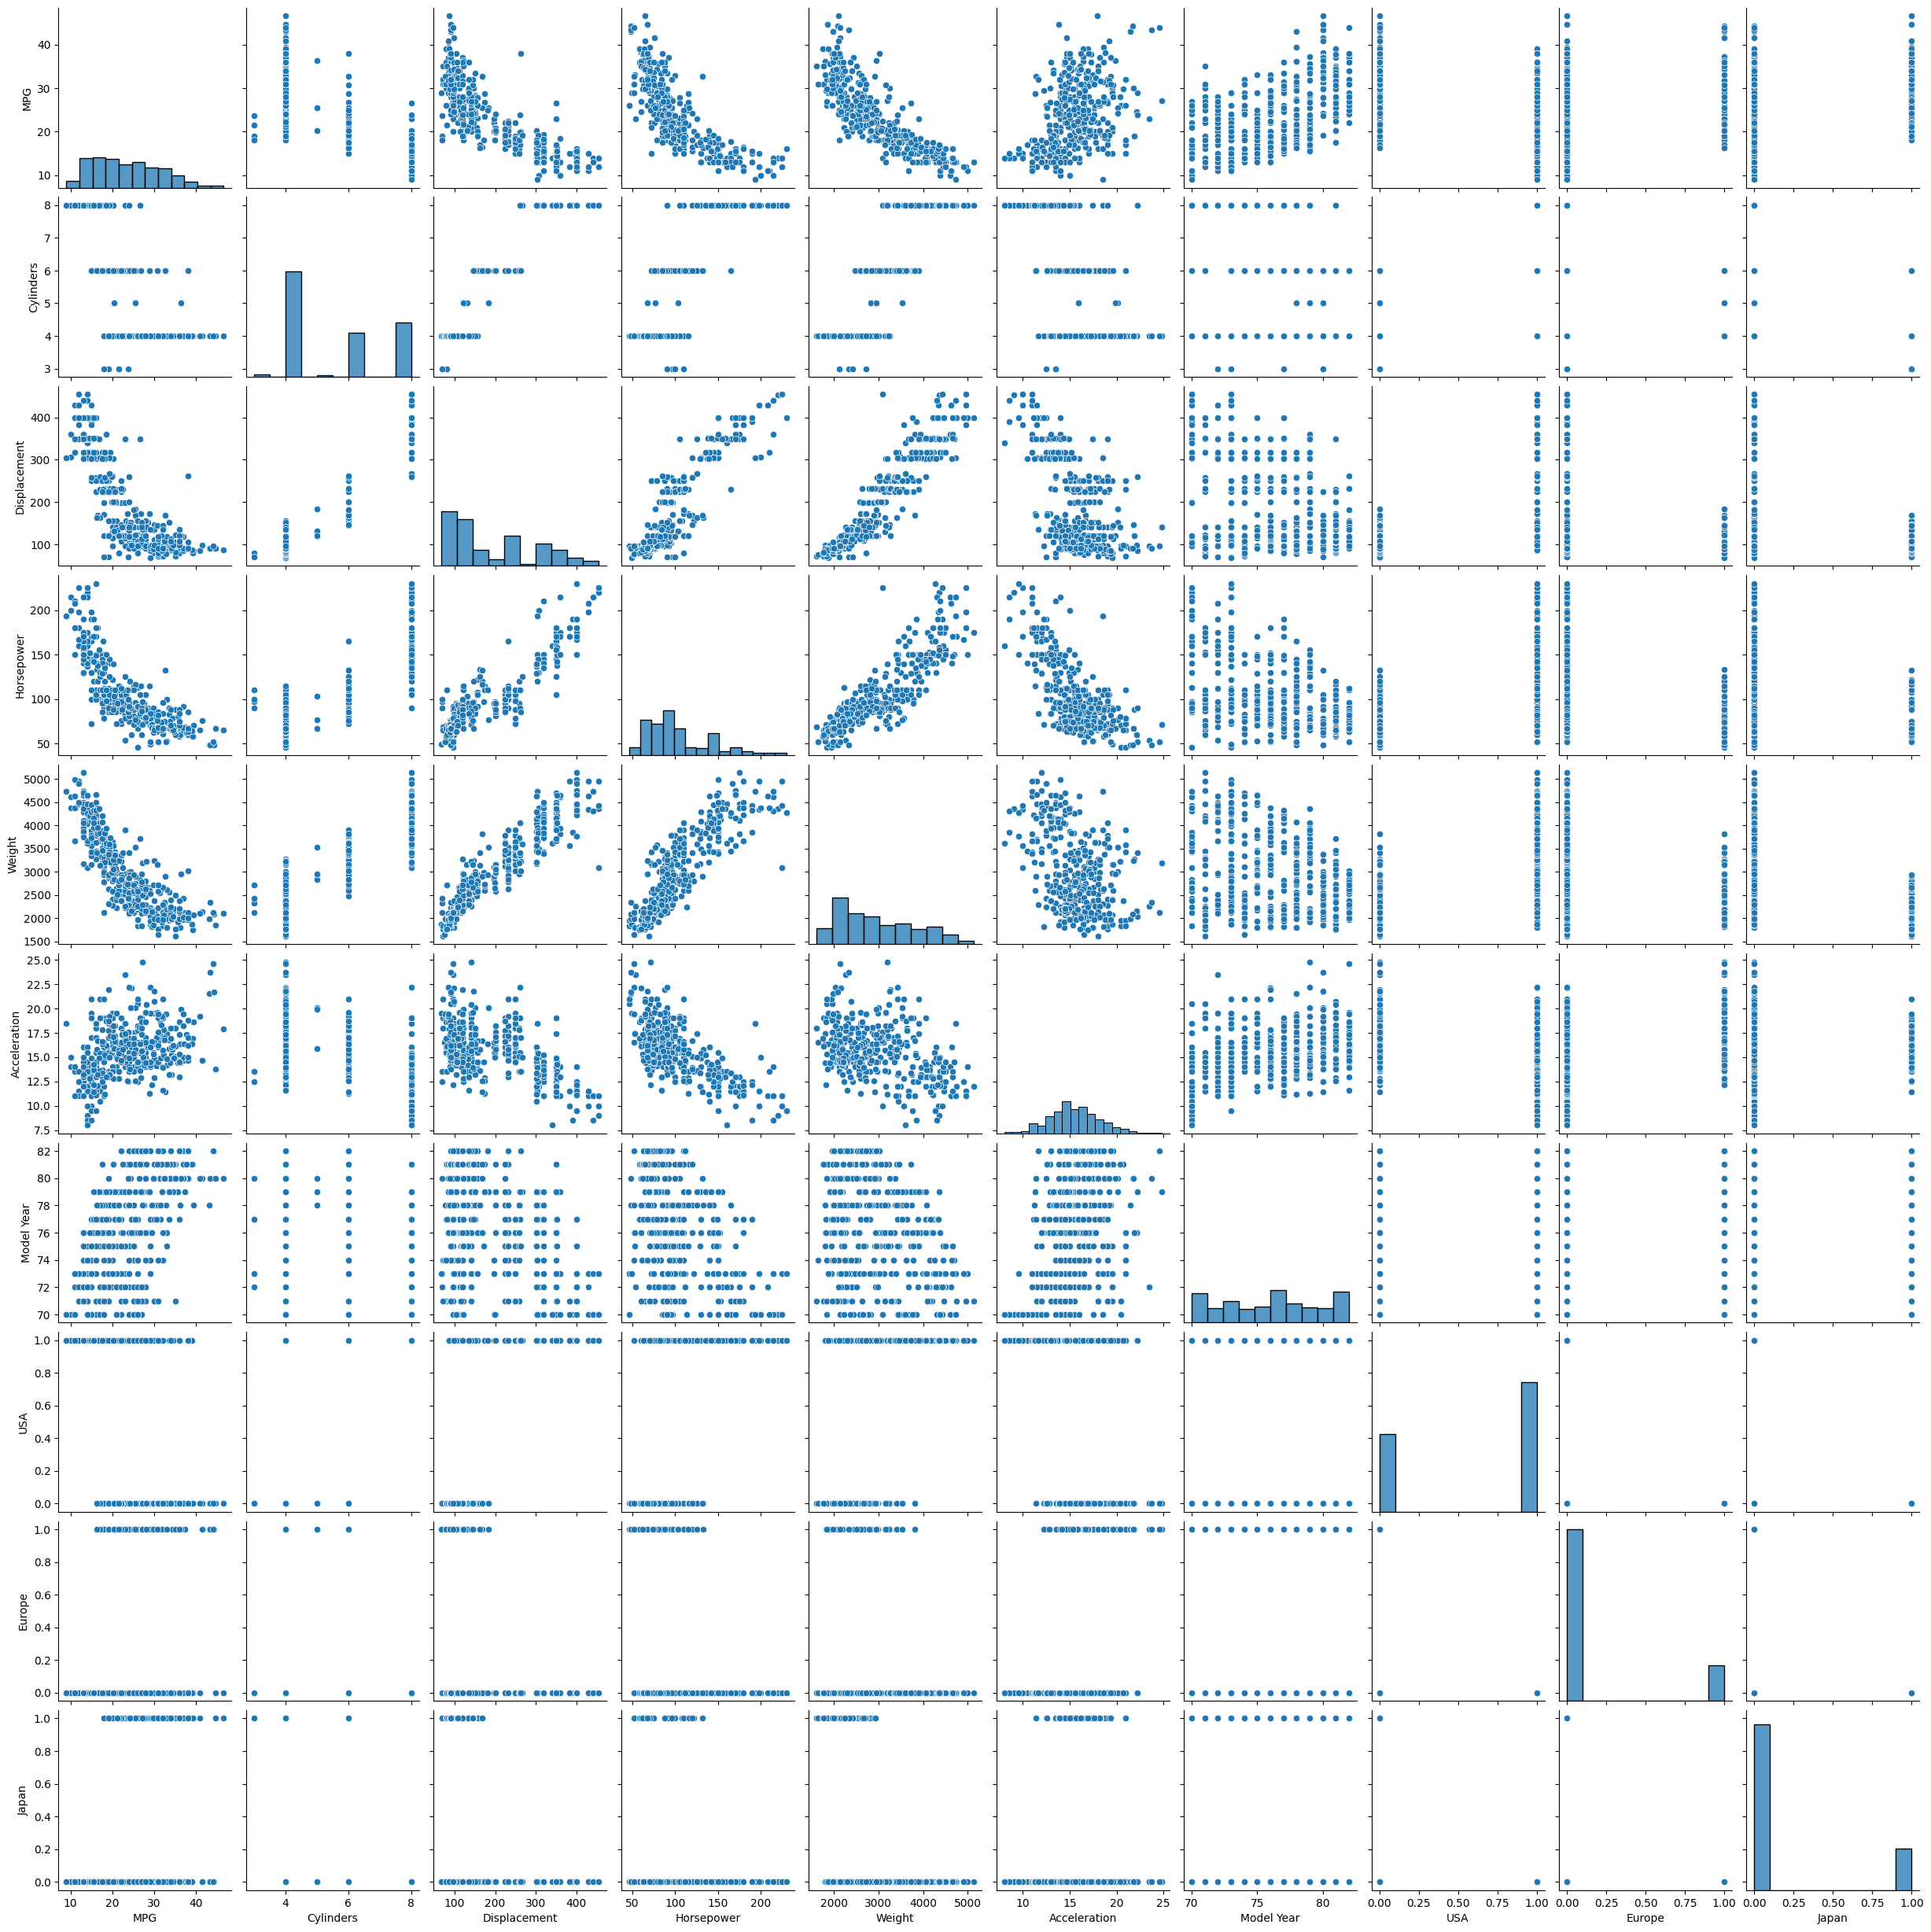

In [129]:
sns.pairplot(dataset2)

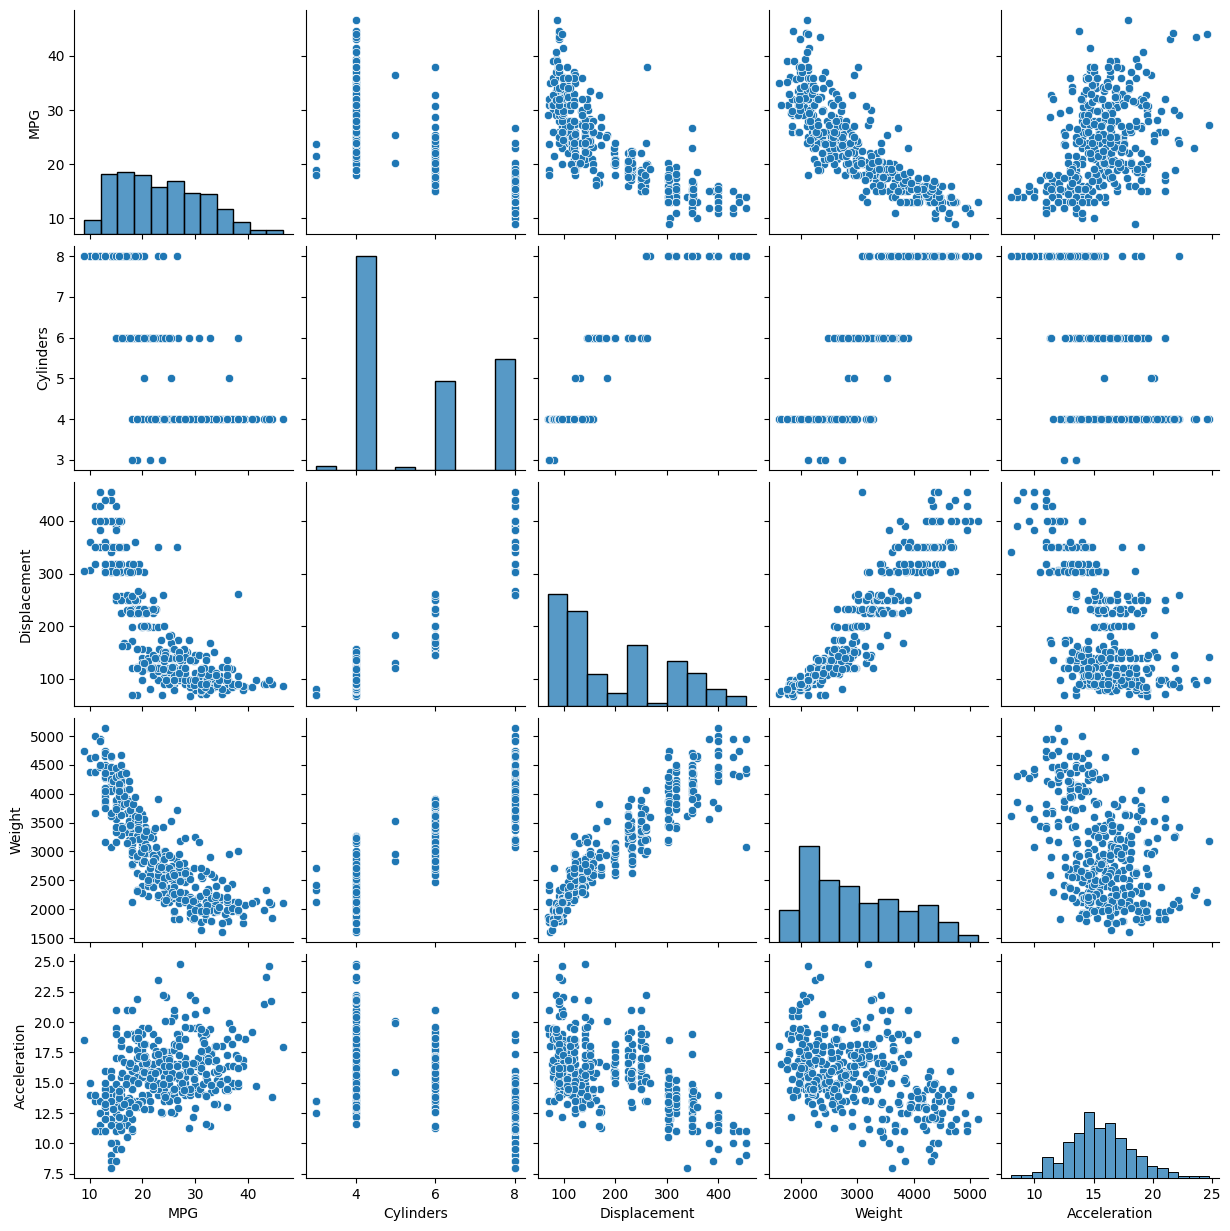

In [130]:
sns.pairplot(dataset2[["MPG", "Cylinders", "Displacement", "Weight","Acceleration"]]) # , diag_kind="kde"

La variable que tipicamente se emplea para predicción es MPG. Ahora observamos las correlaciones que existen entre todas la variables.

---



# **12.5. Otros gráficos relevantes**

## **12.5.1. Matriz de correlación**

### **¿QUÉ CORRELACIÓN?**

La correlación es un **tipo de asociación entre dos variables numéricas**, específicamente evalúa la tendencia (creciente o decreciente) en los datos.
Dos variables se correlacionan cuando muestran una tendencia creciente o decreciente

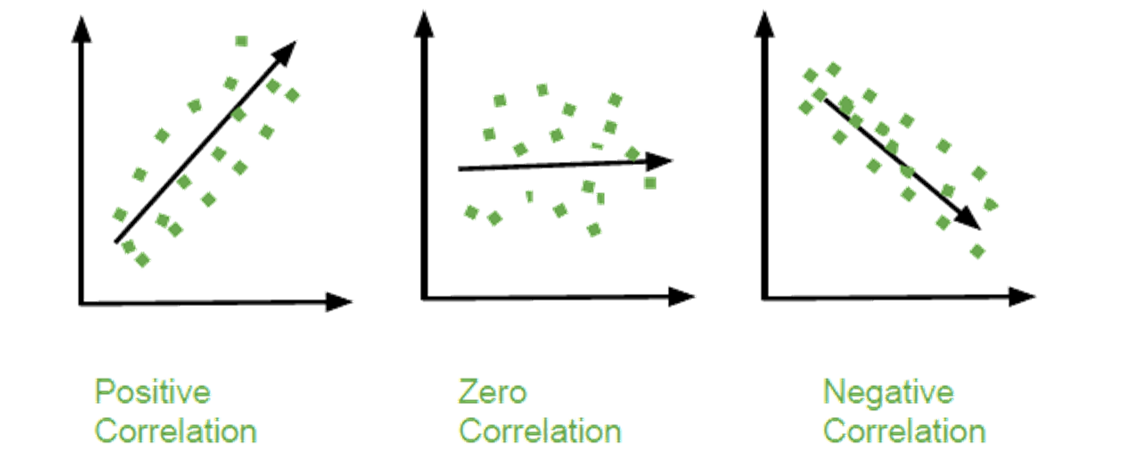

Para determinar si existe una correlación es necesario obtener el **coeficiente de correlación `"r"`**, que mide la fuerza, dirección y extensión entre dos variables. Este valor oscila entre `-1` y `1`:

* Si el resultado es cercano a `1`, existe una correlación positiva fuerte entre las variables.
* Si el resultado es cercano a `-1`, existe una correlación negativa fuerte entre las variables.
* Si el coeficiente es cercano a `0`, no hay correlación entre las variables analizadas.





### **¿QUÉ ES UN MATRIZ DE CORRELACIÓN?**

Una matriz de correlación es una tabla que muestra la relación lineal entre varios pares de variables
Cada celda de la matriz contiene el coeficiente de correlación entre dos variables


In [131]:
corr = dataset2.corr()
print(corr)

                   MPG  Cylinders  Displacement  Horsepower    Weight  \
MPG           1.000000  -0.777618     -0.805127   -0.778427 -0.832244   
Cylinders    -0.777618   1.000000      0.950823    0.842983  0.897527   
Displacement -0.805127   0.950823      1.000000    0.897257  0.932994   
Horsepower   -0.778427   0.842983      0.897257    1.000000  0.864538   
Weight       -0.832244   0.897527      0.932994    0.864538  1.000000   
Acceleration  0.423329  -0.504683     -0.543800   -0.689196 -0.416839   
Model Year    0.580541  -0.345647     -0.369855   -0.416361 -0.309120   
USA          -0.565161   0.610494      0.655936    0.489625  0.600978   
Europe        0.244313  -0.352324     -0.371633   -0.284948 -0.293841   
Japan         0.451454  -0.404209     -0.440825   -0.321936 -0.447929   

              Acceleration  Model Year       USA    Europe     Japan  
MPG               0.423329    0.580541 -0.565161  0.244313  0.451454  
Cylinders        -0.504683   -0.345647  0.610494 -0.35

[]

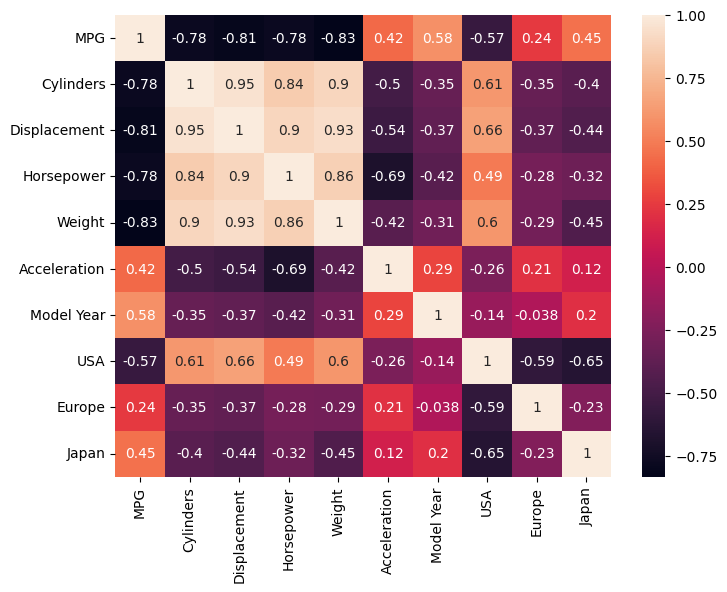

In [132]:
plt.figure(figsize=(8,6))
sns.heatmap(dataset2.corr(), annot=True )  # , cmap='turbo'
plt.plot()

In [133]:
from matplotlib import colormaps
print(list(colormaps))

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

***
## **12.5.2. Gráficos de cajas (Box Plot)**

Para ver la distribución de una variable numérica a través de diferentes categorías. Este tipo de gráfico es ideal si tienes una variable numérica que quieres analizar en relación con una categórica.

Un boxplot, también conocido como diagrama de caja y bigotes, es una herramienta estadística que permite visualizar la distribución de un conjunto de datos a través de sus cuartiles. A diferencia de un histograma, no muestra la frecuencia exacta, sino que resume la "forma" de los datos en cinco números clave: el valor mínimo, el primer cuartil (Q1), la mediana (Q2), el tercer cuartil (Q3) y el valor máximo.


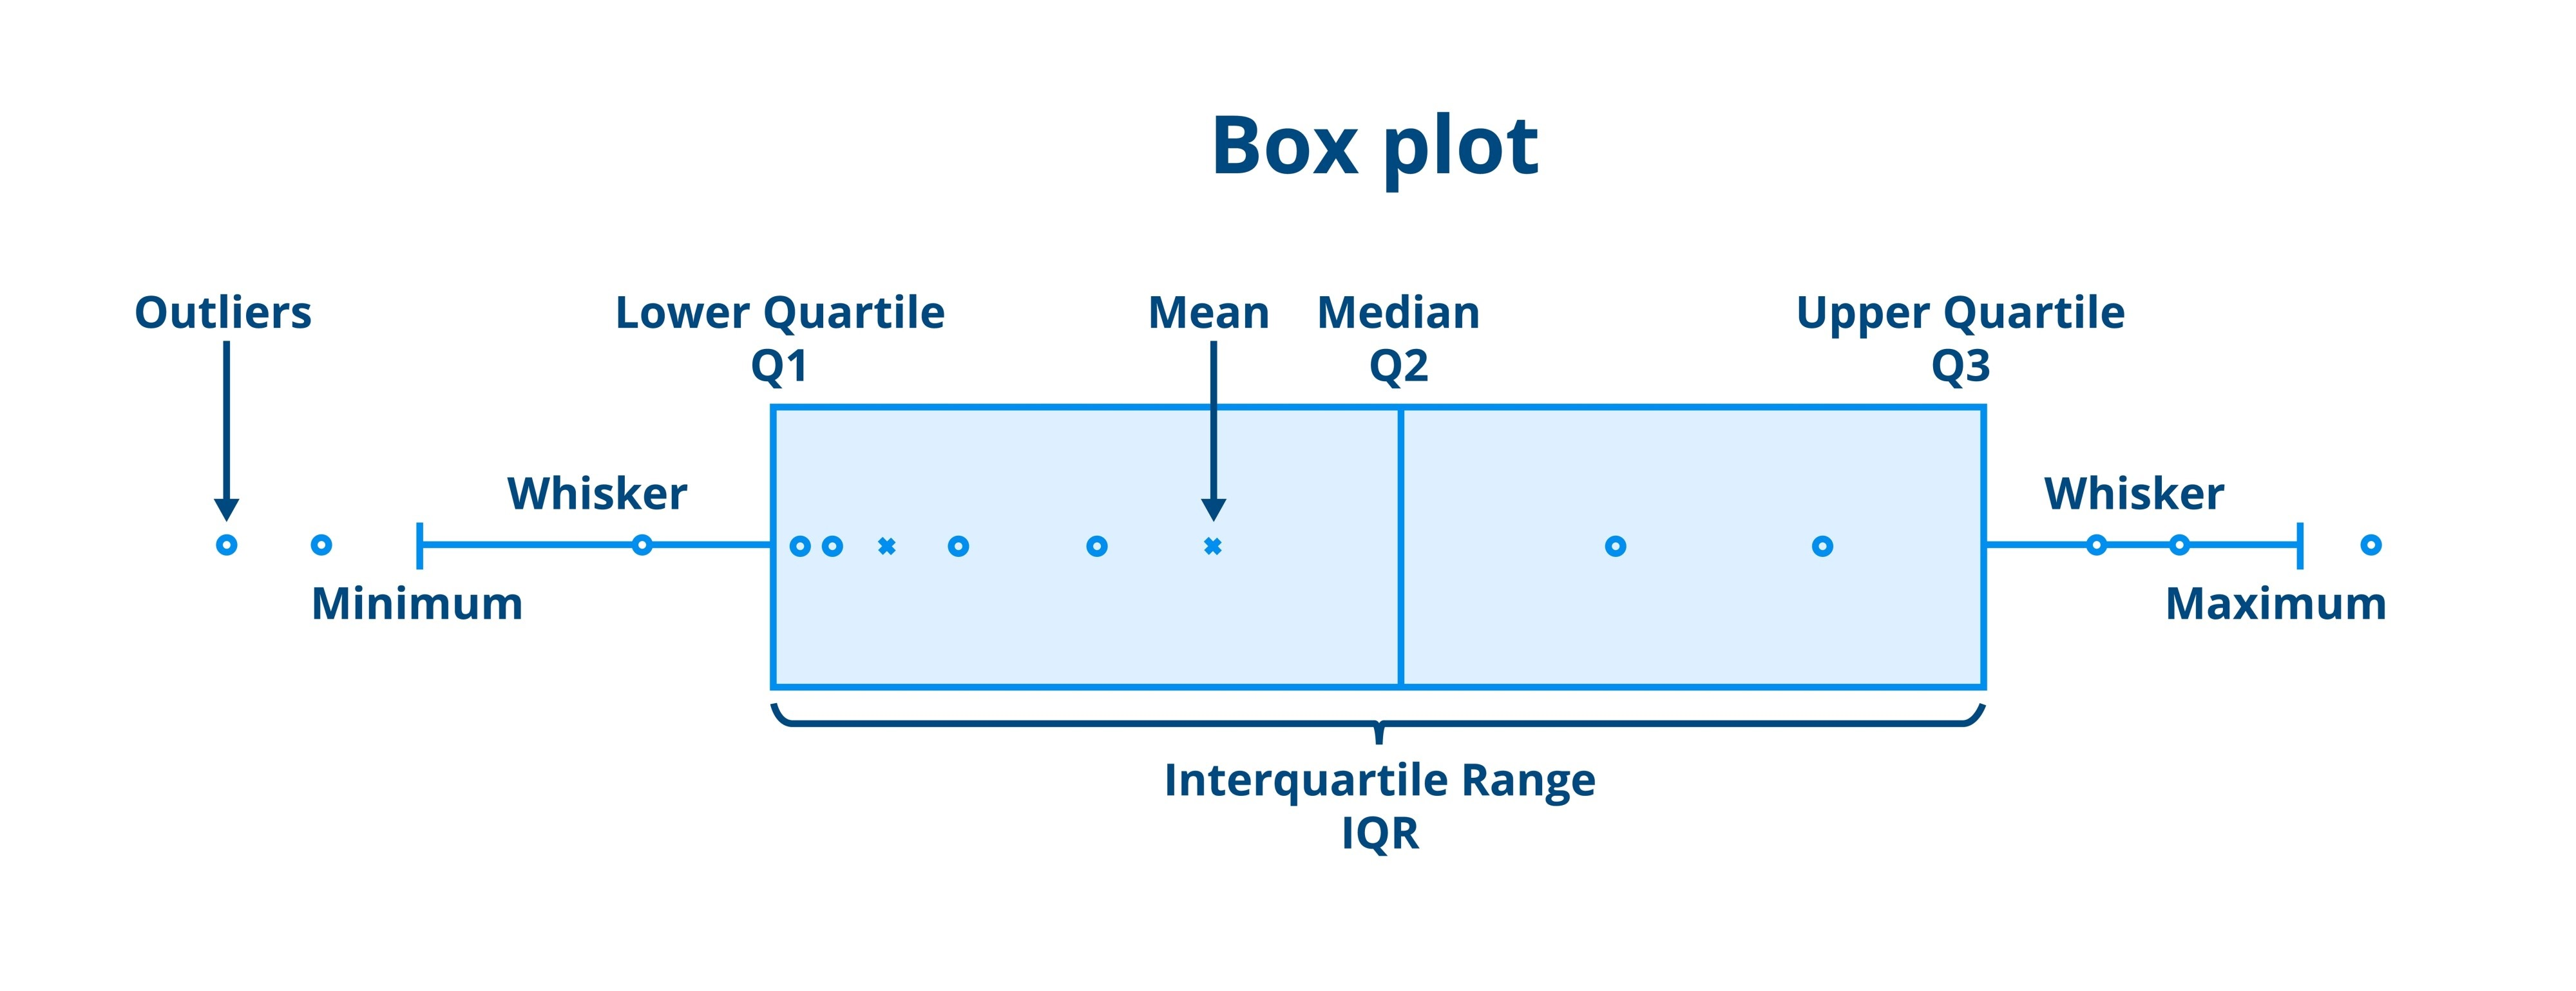

**¿Cuándo es ideal utilizarlos?**

Es uno de los gráficos favoritos en la ciencia de datos por su capacidad de síntesis. Es especialmente útil en los siguientes casos:

* **Identificación de outliers**: Es la mejor herramienta visual para detectar valores atípicos (esos puntos que quedan fuera de los "bigotes") que podrían sesgar un análisis.

* **Comparación de grupos**: Permite comparar rápidamente la dispersión y la mediana de diferentes categorías (por ejemplo, comparar los puntajes de matemáticas entre distintos grupos de preparación).

* **Simetría y sesgo**: Ayuda a ver si los datos están concentrados en los valores bajos, en los altos o si se distribuyen de forma uniforme.

* **Ahorro de espacio**: Puedes poner 10 boxplots uno al lado del otro para comparar 10 categorías distintas y la gráfica seguirá siendo perfectamente legible.

**Datos claves:**
1. La "caja" representa el rango intercuartílico (IQR), donde se encuentra el 50% central de tus datos. Si la caja es muy larga, los datos están muy dispersos; si es corta, están muy concentrados.
2. Los límites superior e inferior de los bigotes se calculan usando el IQR:
- $Limite_{inf} = Q1 - (1.5 \times IQR)$
- $Limite_{sup} = Q3 - (1.5 \times IQR)$
3. El bigote no llega exactamente al límite calculado, sino al dato real más lejano que esté dentro de ese rango.

<Axes: >

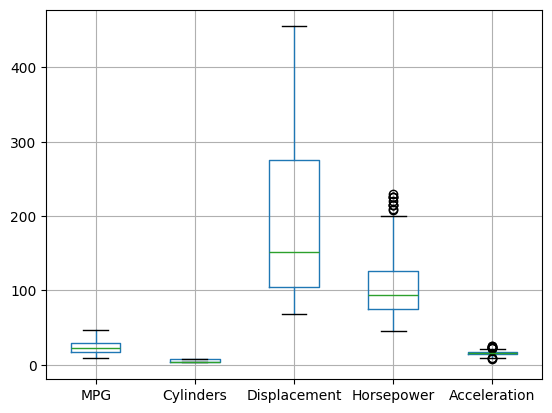

In [134]:
dataset2.boxplot(column=['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Acceleration'])

**Segmentación por categorías:**
* Se puede utilizar uno de los ejes para segmentar el gráfico por categorías. Por defecto esta segmentación se hace con el eje horizontal.

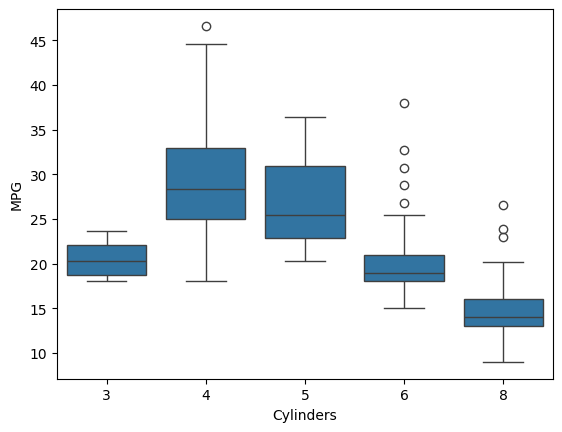

In [135]:
sns.boxplot(x='Cylinders', y='MPG', data=dataset2)  #  x='Horsepower'
plt.show()

* También se puede hacer la segmentación usando el eje vertical.

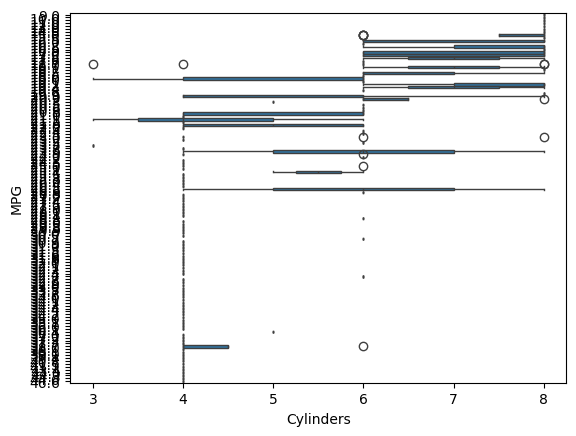

In [136]:
sns.boxplot(x='Cylinders', y='MPG', data=dataset2, orient='h')  # , orient='h'
plt.show()

***
## **12.5.3. Gráfico de Violin (Violin Plot)**


Un gráfico de violín es esencialmente una evolución del boxplot. Combina la información estadística de una caja y bigotes con un diagrama de densidad de kernel (KDE).

Básicamente, es como si pusieras un boxplot en el centro y le pegaras a los lados una silueta que representa qué tan frecuentes son los valores en cada punto. Mientras más ancha sea la "panza" del violín, más datos hay concentrados en ese nivel.

**¿Cuándo es ideal utilizarlos?**
Es la herramienta definitiva cuando los boxplots se quedan "cortos" en información. Úsalos en estos casos:

* **Distribuciones multimodales**: Si tus datos tienen dos o más picos de concentración (por ejemplo, notas que se agrupan en "muy alto" y "muy bajo"), un boxplot solo te mostrará una caja aburrida. El violín, en cambio, mostrará claramente los dos ensanchamientos.

* **Grandes volúmenes de datos:** Cuando tienes miles de registros, los puntos individuales (outliers) pueden saturar un gráfico, pero la silueta del violín te permite ver la masa de los datos de forma fluida.

* **Análisis estético y profesional:** En reportes avanzados o publicaciones científicas, ofrecen una visión mucho más rica y moderna de la estructura de los datos que un gráfico de barras o un boxplot tradicional.

* **Comparación de densidades:** Son excelentes para ver si una categoría está más "dispersa" o "concentrada" que otra de un solo vistazo.

**Nota técnica:** A diferencia del boxplot, el violín no te permite identificar puntos atípicos (outliers) individuales con tanta facilidad a menos que le añadas los puntos originales encima (un "swarm plot" o "strip plot").

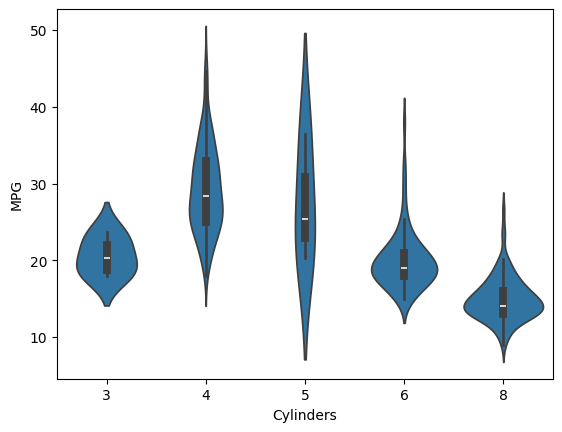

In [137]:
sns.violinplot(x='Cylinders', y='MPG', data=dataset2)
plt.show()

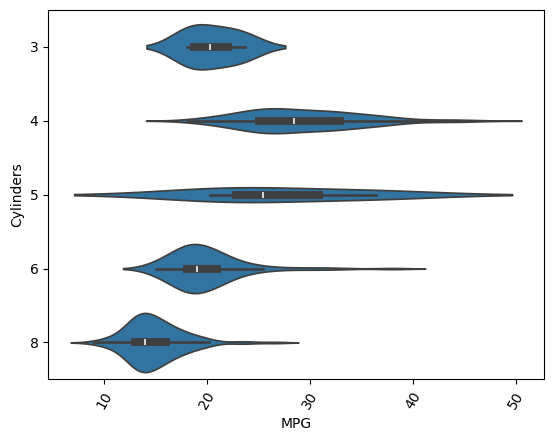

In [138]:
sns.violinplot(x='MPG', y='Cylinders', data=dataset2, orient='h')
plt.xticks(rotation=60)
plt.show()

***
## **12.5.4. Gráfico de Sectores o Torta (Pie Chart)**

Un pie chart, o gráfico de pastel, es una herramienta de visualización circular dividida en sectores o "rebanadas" que se utiliza para ilustrar proporciones numéricas. En este tipo de gráfico, cada sector es proporcional a la cantidad que representa respecto al total (el 100%).

**¿Cuándo es ideal utilizarlos?**

Aunque son muy comunes, su efectividad depende totalmente del contexto de los datos. Son recomendables cuando:
* **Partes de un todo**: Su función principal es mostrar cómo se descompone una variable única en diferentes categorías.
* **Pocas categorías**: Funcionan mejor cuando hay entre 2 y 5 categorías. Si hay demasiadas rebanadas, el gráfico se vuelve difícil de leer.
* **Diferencias notables**: Son útiles cuando los datos tienen valores muy distintos entre sí, permitiendo identificar a simple vista cuál es la categoría dominante.
* **Datos nominales**: Se utilizan para categorías que no tienen un orden intrínseco (como género, departamentos de una empresa o tipos de dispositivos).

**Regla de oro:** Si necesitas que el espectador compare con precisión valores muy similares o si tienes más de 7 categorías, es preferible optar por un gráfico de barras. El ojo humano es mucho mejor comparando longitudes que áreas o ángulos.

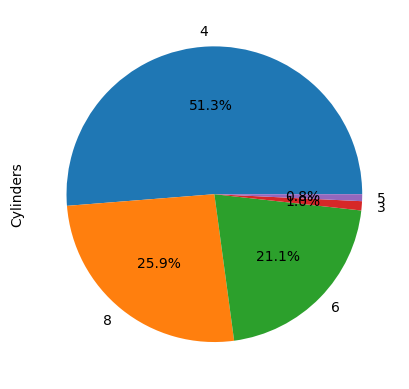

In [139]:
dataset['Cylinders'].value_counts().plot.pie(autopct='%1.1f%%')  # MPG
plt.ylabel('Cylinders')
plt.show()

***
# **12.5. Filtrando los datos**

Supongamos que queremos graficar el histograma de Horsepower solo de los datos de USA.

In [140]:
dataset2.columns

Index(['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
       'Acceleration', 'Model Year', 'USA', 'Europe', 'Japan'],
      dtype='object')

<Axes: ylabel='Frequency'>

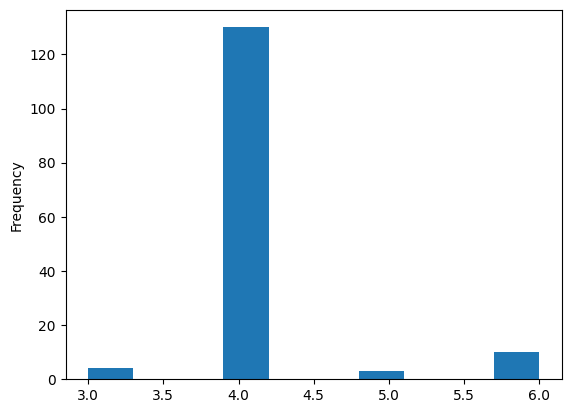

In [141]:
dataset2[dataset2['USA']==0]['Cylinders'].plot.hist()

<Axes: ylabel='Frequency'>

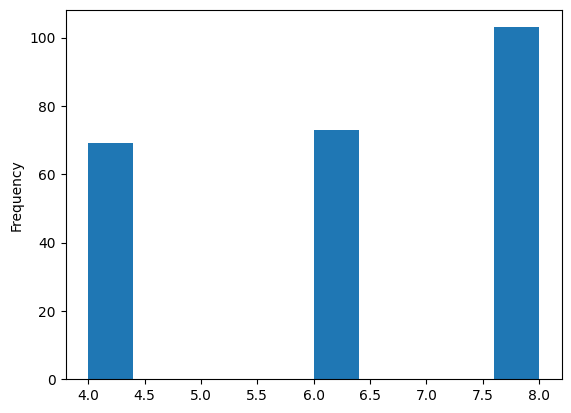

In [142]:
dataset2[dataset2['USA']]['Cylinders'].plot.hist()

<Axes: ylabel='Frequency'>

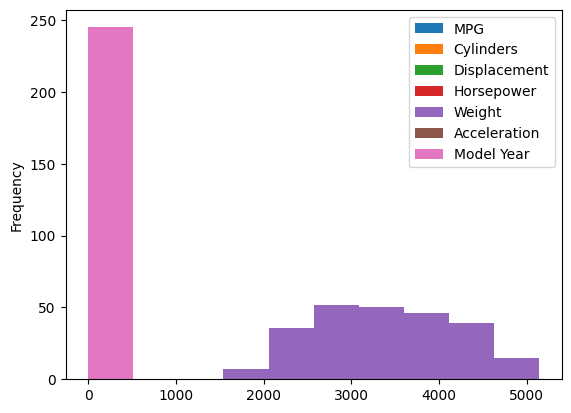

In [143]:
dataset2[dataset2['USA']==1].plot.hist()

<Axes: ylabel='Frequency'>

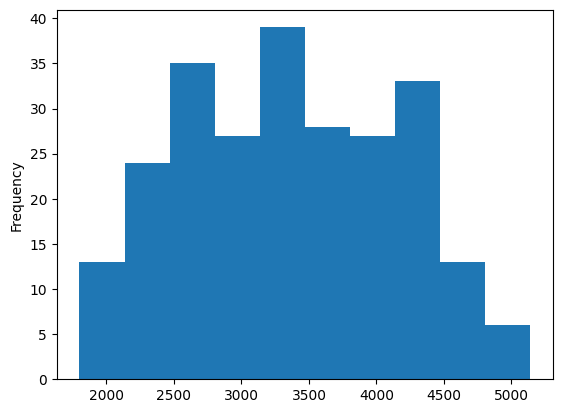

In [144]:
dataset2[dataset2['USA']==1]['Weight'].plot.hist()

***
# **12.5. Determinar valores maximos y minimos**
Podemos hacer uso de los comandos `min` y `max`, como tambien de los comando `argmax` y `argmin`.

In [145]:
dataset2

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,USA,Europe,Japan
0,18.0,8,307.0,130.0,3504.0,12.0,70,True,False,False
1,15.0,8,350.0,165.0,3693.0,11.5,70,True,False,False
2,18.0,8,318.0,150.0,3436.0,11.0,70,True,False,False
3,16.0,8,304.0,150.0,3433.0,12.0,70,True,False,False
4,17.0,8,302.0,140.0,3449.0,10.5,70,True,False,False
...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,True,False,False
394,44.0,4,97.0,52.0,2130.0,24.6,82,False,True,False
395,32.0,4,135.0,84.0,2295.0,11.6,82,True,False,False
396,28.0,4,120.0,79.0,2625.0,18.6,82,True,False,False


In [146]:
print('Ubicacion del maximo :', dataset2['MPG'].argmax())

Ubicacion del maximo : 320


In [147]:
print('La etiqueta del maximo :', dataset2['MPG'].idxmax())

La etiqueta del maximo : 322


In [148]:
print('Valor del maximo :', dataset2['MPG'].max())

Valor del maximo : 46.6


***
# **Ejercicio**
1. Determinar el valor maximo y minimo de Horsepower para cada Origen. a) Filtrando los datos. b) Usando `groupby`.

In [149]:
#Hacer codigo aqui

2. Determinar el numero de los registro (fila) donde estan ubicados los maximos y minimos de MPG, Horsepower y Acceleration. Indicar cual es el año del modelo y el pais de origen en cada caso.